### linear regression gradient descent derivation

In [6]:
import numpy as np
# data set
rng=np.random.RandomState(42)
x=np.linspace(0,10,101)
y=x*2+1+rng.randn(101)-0.5
w,b=rng.randn(2)
w=w*2+1
b=b*2

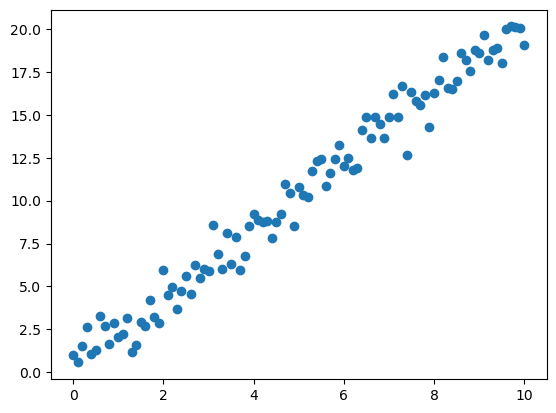

In [7]:
#visualize the data
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [8]:
# function culculation: with vector as input
def forward(x,w,b):
    return x*w+b
def loss(pre,true):
    mid=true-pre
    return np.dot(mid,mid)
def dw(x,y,w,b):
    return 2 * np.mean(x * (w*x + b - y))
def db(x,y,w,b):
    return 2 * np.mean(w*x + b - y)


### gradient descent derivation

In [4]:
def derive(x,y,w,b,lr=0.01,ti=100):
    lossv =[]
    for i in range(ti):
        w=w-dw(x,y,w,b)*lr
        b=b-db(x,y,w,b)*lr
        lossv.append(loss(forward(x,w,b),y))
    return w,b,lossv

### traning & visualize

In [9]:
length=0.01
times=100
w_a,b_a,loss_a=derive(x,y,w,b,length,times)
print(f"the result:y={w_a:.4f}x+{b_a:.4f}")
print(f"loss={loss_a[-1]}")

the result:y=2.0912x+-0.2138
loss=91.58276178848367


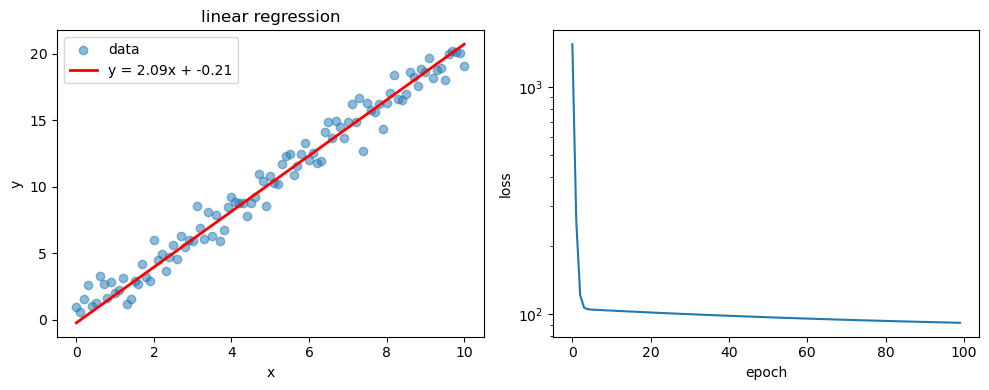

In [10]:
y_line = forward(x, w_a, b_a)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(x, y, alpha=0.5, label='data')
label_text = 'y = {:.2f}x + {:.2f}'.format(w_a, b_a)
plt.plot(x, y_line, 'r-', linewidth=2, label=label_text)
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('linear regression')
plt.subplot(1, 2, 2)
plt.plot(loss_a)
plt.xlabel('epoch'); plt.ylabel('loss'); plt.yscale('log')
plt.tight_layout(); plt.show()


# Part 2: Logistic Regression

In [ ]:
def sigmoid(z):
    x=1+np.exp(-z)
    return 1/x

In [ ]:
def binary_cross_entropy(y_pred, y_true):
    sum(y*log(y_pred) + (1-y)*log(1-y_pred)) / N
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss


In [ ]:
def logistic_gradients(X, y, w, b):
    z=X@w+b
    h=sigmoid(z)
    dw=np.mean((y-h)*X)
    db=np.mean(y-h)
    return dw,db

In [ ]:
def train_logistic_regression(X, y, lr=0.01, epochs=1000):
    loss=[]
    shape=x.shape[1]
    w=np.zeros(shape)
    b=0
    for i in range(epochs):
        dw,db=train_logistic_regression(X,y,w,b)
        w-=lr*dw
        b-=lr*db
        loss.append(binary_cross_entropy(sigmoid(X@w+b),y))
    return w,b,loss

In [ ]:
def predict_logistic(X, w, b, threshold=0.5):
    prob = sigmoid(X @ w + b)
    return (prob >= threshold).astype(int)

In [ ]:
def plot_decision_boundary(X, y, w, b):
    """
    画出逻辑回归的决策边界
    用 contourf 画出分类区域，scatter 画出样本点
    提示: 在 meshgrid 上计算 sigmoid(X@w+b)，画等高线
    """
    pass

### 桥接思考：逻辑回归 = 单层神经网络

> 逻辑回归的前向传播: X@w+b -> sigmoid -> 输出
> 
> 神经网络的一层: X@W+b -> activation -> 输出
>
> **数学结构完全一样。** 区别只有：
> 1. 神经网络有多个神经元（多个 w, b 组合）
> 2. 多个神经元堆叠形成隐藏层
> 3. 中间加 ReLU 等非线性激活函数

In [ ]:
# 对比分析：逻辑回归 vs 神经网络的一个神经元
# 请在下面写出你的理解

def compare_logistic_vs_nn():
    """
    比较逻辑回归和单层神经网络的异同
    输出: 打印对比表格或文字
    """
    pass

# Part 3: 2-Layer Neural Network (NumPy)

In [ ]:
def relu(z):
    """
    ReLU 激活函数: max(0, z)
    输入: z - numpy 数组
    输出: relu(z)
    """
    pass

In [ ]:
def softmax(z):
    """
    Softmax 激活函数，把 logits 转成概率分布
    输入: z - (batch_size, n_classes)
    输出: softmax 概率 (每行和为 1)
    注意: 减去 max(z) 防止数值溢出
    """
    pass

In [ ]:
def cross_entropy(y_pred, y_true):
    """
    多分类交叉熵损失
    输入: y_pred - softmax 输出 (batch_size, n_classes)
          y_true - one-hot 编码的真实标签 (batch_size, n_classes)
    输出: 标量 loss
    """
    pass

In [ ]:
def forward_nn(X, W1, b1, W2, b2):
    """
    2 层神经网络前向传播
    输入: X - (batch_size, 2) 输入特征
          W1 - (2, hidden_size) 隐藏层权重
          b1 - (hidden_size,) 隐藏层偏置
          W2 - (hidden_size, n_classes) 输出层权重
          b2 - (n_classes,) 输出层偏置
    输出:
          h - ReLU(W1@X + b1) 隐藏层输出
          out - softmax(W2@h + b2) 最终输出
    维度提示: 注意转置，保证矩阵乘法对齐
    """
    pass

In [ ]:
def backward_nn(X, y_onehot, W1, b1, W2, b2, h, out):
    """
    2 层神经网络反向传播（手动链式求导）
    输入: X, y_onehot, W1, b1, W2, b2 - 参考 forward_nn
          h - 隐藏层输出
          out - 最终输出概率
    输出: dW1, db1, dW2, db2

    推导提示:
      1. dout = (out - y_onehot) / batch_size  (softmax + cross-entropy 的梯度)
      2. dW2 = h.T @ dout
      3. db2 = sum(dout, axis=0)
      4. dh = dout @ W2.T，再乘 relu 的导数 (h > 0)
      5. dW1 = X.T @ dh
      6. db1 = sum(dh, axis=0)

    维度检查:
      dW1.shape == W1.shape, dW2.shape == W2.shape
      db1.shape == b1.shape, db2.shape == b2.shape
    """
    pass

In [ ]:
def train_nn(X, y, hidden_size=3, lr=0.01, epochs=1000):
    """
    训练 2 层神经网络
    输入: X - 训练数据 (n_samples, 2)
          y - 标签 (n_samples,)
          hidden_size - 隐藏层神经元数
          lr - 学习率
          epochs - 迭代次数
    输出: params = {W1, b1, W2, b2}, loss_history

    实现步骤:
      1. 初始化参数（小随机数）
      2. y -> one-hot 编码
      3. 循环 epochs:
         - forward -> loss
         - backward -> 梯度
         - update: param -= lr * grad
         - 记录 loss
      4. 画 loss 下降曲线
    """
    pass

In [ ]:
def predict_nn(X, W1, b1, W2, b2):
    """
    神经网络预测
    输入: X, W1, b1, W2, b2
    输出: 预测类别 (n_samples,)
    """
    pass

In [ ]:
def plot_nn_decision_boundary(X, y, W1, b1, W2, b2):
    """
    画出神经网络学到的决策边界
    对比逻辑回归的决策边界，观察非线性分界能力
    """
    pass

# Part 4: 数据持久化与 sklearn 验证

In [ ]:
def save_weights(filepath, **params):
    """
    将模型权重保存为 .npy 文件
    用法: save_weights('model.npy', W1=W1, b1=b1, W2=W2, b2=b2)
    提示: 用 np.savez() 或 np.save()
    """
    pass

In [ ]:
def load_weights(filepath):
    """
    从 .npy 文件加载模型权重
    输出: dict 包含所有参数
    """
    pass

In [ ]:
def verify_with_sklearn(X, y):
    """
    用 sklearn 验证你的手写实现
    1. 在 Iris 或 make_moons 上跑 sklearn 的:
       - LogisticRegression
       - MLPClassifier (hidden_layer_sizes=(3,))
    2. 对比准确率
    3. 对比决策边界（画在同一张图上）
    4. 输出结论

    预期: 手写版和 sklearn 版的决策边界应该大致相似
    """
    pass

### 完成清单

- [ ] 线性回归: forward / loss / gradients / train / predict / plot (已完成)
- [ ] 逻辑回归: sigmoid / cross_entropy / gradients / train / predict / boundary
- [ ] 桥接思考: 理解逻辑回归 = 单层神经元
- [ ] 2 层 NN: relu / softmax / forward / backward / train / predict / boundary
- [ ] 权重保存: save_weights / load_weights
- [ ] sklearn 验证: verify_with_sklearn